In [117]:
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [118]:
df=pd.read_csv('Telco_cleaned.csv')

In [119]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [160]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

Feature selection

In [121]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [122]:
df = df.drop('customerID', axis=1, errors='ignore')

START THE TRAINING

In [123]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [124]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [125]:
X_train.shape,y_train.shape,y_test.shape

((5634, 30), (5634,), (1409,))

In [126]:
X.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,-0.001874,0.016479,-0.211185,0.008576,-0.008576,0.142948,...,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477
tenure,0.016567,1.000000,0.247900,0.826178,0.005106,0.379697,0.159712,0.008448,-0.008448,0.331941,...,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,-0.014569,0.096848,-0.113890,0.247398,-0.247398,0.490434,...,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.000080,0.317504,0.062078,0.113214,-0.113214,0.468504,...,-0.375223,0.514973,-0.375223,0.520122,0.170814,0.354481,0.158574,0.182915,-0.059246,-0.295758
gender_Male,-0.001874,0.005106,-0.014569,-0.000080,1.000000,-0.001808,0.010517,-0.006488,0.006488,-0.008414,...,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744
Partner_Yes,0.016479,0.379697,0.096848,0.317504,-0.001808,1.000000,0.452676,0.017706,-0.017706,0.142057,...,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125
Dependents_Yes,-0.211185,0.159712,-0.113890,0.062078,0.010517,0.452676,1.000000,-0.001762,0.001762,-0.024526,...,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071
PhoneService_Yes,0.008576,0.008448,0.247398,0.113214,-0.006488,0.017706,-0.001762,1.000000,-1.000000,0.279690,...,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,0.016505,-0.007721,0.003062,-0.003319
MultipleLines_No phone service,-0.008576,-0.008448,-0.247398,-0.113214,0.006488,-0.017706,0.001762,-1.000000,1.000000,-0.279690,...,-0.172209,0.022574,-0.172209,0.032959,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319
MultipleLines_Yes,0.142948,0.331941,0.490434,0.468504,-0.008414,0.142057,-0.024526,0.279690,-0.279690,1.000000,...,-0.210564,0.257152,-0.210564,0.258751,-0.003794,0.106253,0.163530,0.060048,0.083618,-0.227206


<Axes: >

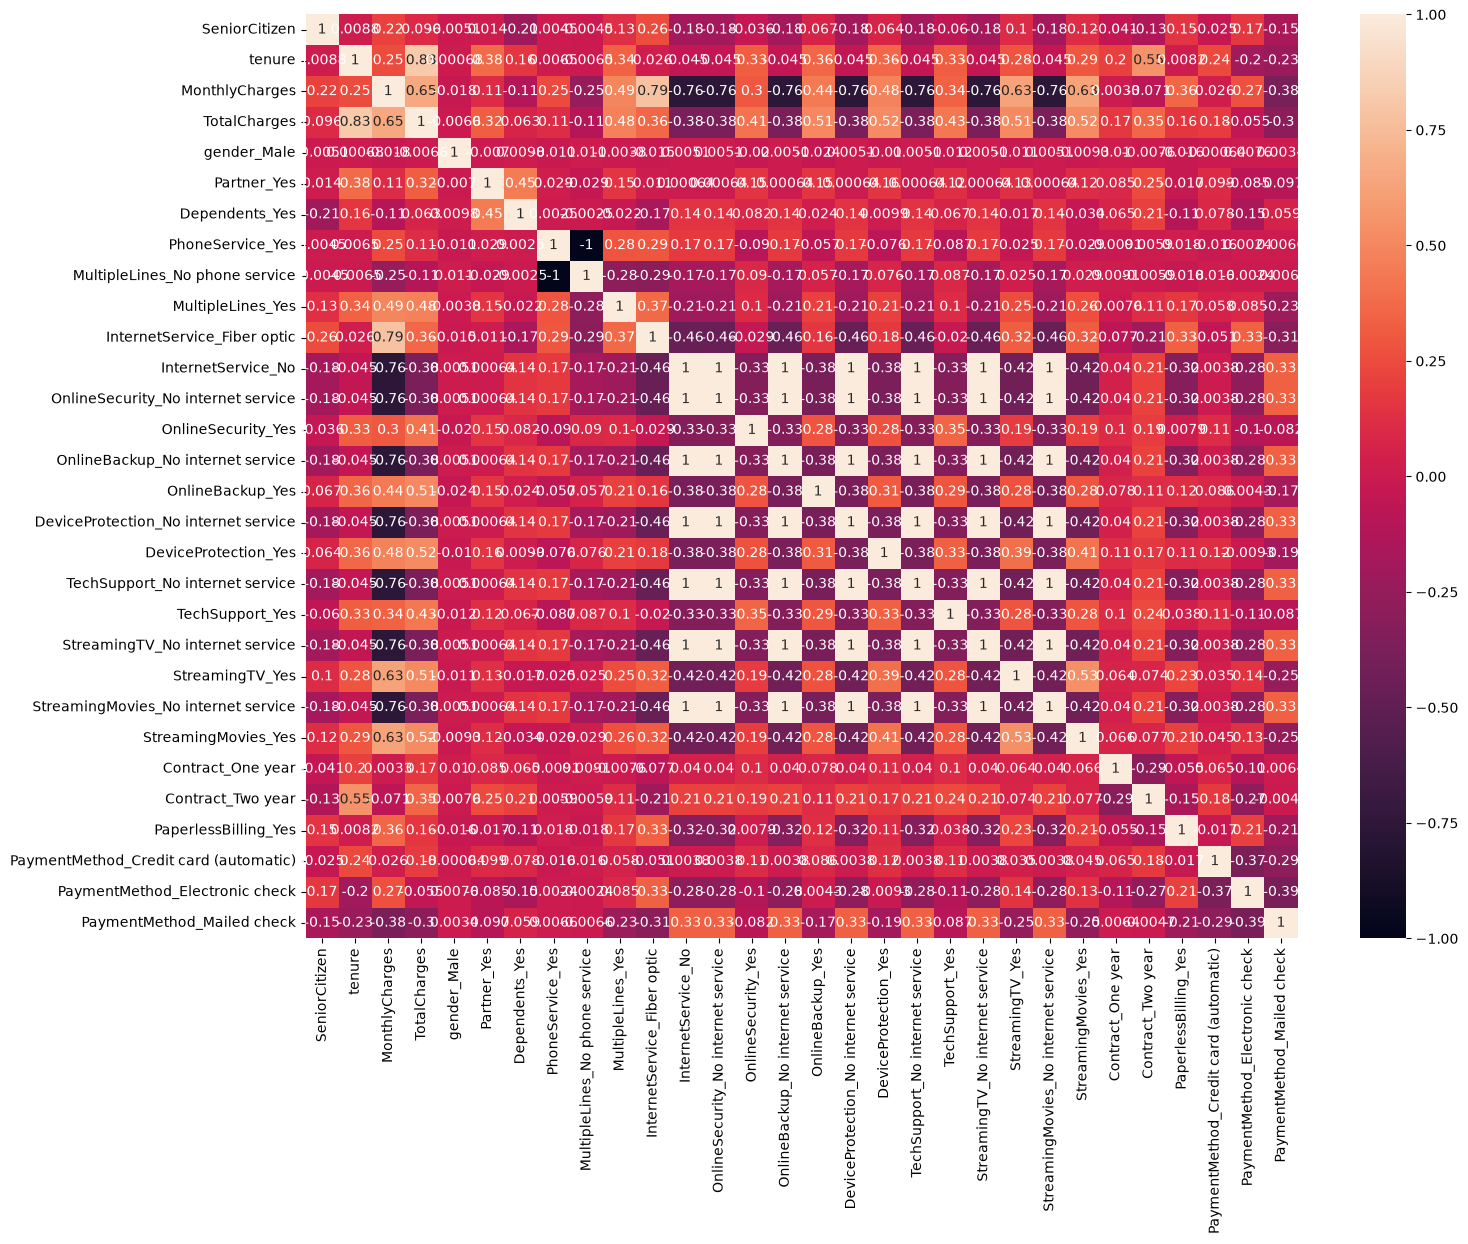

In [127]:
import seaborn as sns
plt.figure(figsize=(16,12))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

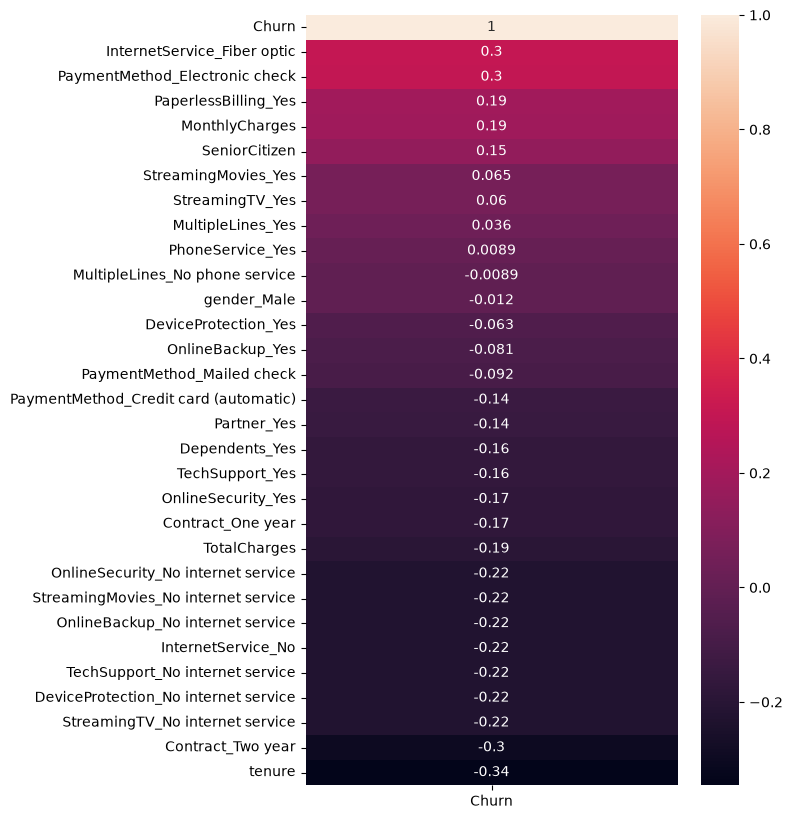

In [128]:
temp_df=X_train.copy()
temp_df['Churn']=y_train

Churn_corr=temp_df.corr()[['Churn']].sort_values(by='Churn',ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(Churn_corr,annot=True)
plt.show()

DROP THE COLUMNS WHICH HAVE VERY MUCH COLLINEARITY IN X_TRAIN COLUMNS AND ALSO DROP THE COLUMNSW WHICH HAVE VERY LESS COLLINEARITY IN THE Y_TRAIN COLUMNS

In [129]:
def optimize_features(X_train, X_test, y_train, noise_threshold=0.05, multi_threshold=0.90):
    
    temp_df = X_train.copy()
    temp_df['Churn'] = y_train

    churn_corr = temp_df.corr()['Churn'].abs().drop('Churn')
    noise_cols = churn_corr[churn_corr < noise_threshold].index.tolist()
    
    X_train_clean = X_train.drop(columns=noise_cols, errors='ignore')
    X_test_clean = X_test.drop(columns=noise_cols, errors='ignore')

    col_corr = set()
    corr_matrix = X_train_clean.corr().abs() 
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > multi_threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    
    X_train_clean = X_train_clean.drop(columns=col_corr, errors='ignore')
    X_test_clean = X_test_clean.drop(columns=col_corr, errors='ignore')

    return X_train_clean, X_test_clean

In [130]:
X_train, X_test = optimize_features(X_train, X_test, y_train, noise_threshold=0.05, multi_threshold=0.90)

In [131]:
X_train.shape

(5634, 20)

STANDARD SCALING

In [132]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
columns_to_scale = [col for col in columns_to_scale if col in X_train.columns]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [133]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [134]:
y_pred=model.predict(X_test)

In [135]:
model.predict_proba(X_test)

array([[0.3516563 , 0.6483437 ],
       [0.948412  , 0.051588  ],
       [0.99508952, 0.00491048],
       ...,
       [0.94570959, 0.05429041],
       [0.98770279, 0.01229721],
       [0.55059506, 0.44940494]], shape=(1409, 2))

In [136]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score=accuracy_score(y_test,y_pred)
print(score*100)
cm=confusion_matrix(y_test,y_pred)
print(cm)
cr=classification_report(y_test,y_pred)
print(cr)

82.18594748048261
[[937  99]
 [152 221]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.59      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



HYPERPARAMETER TUNNING

In [ ]:
model=LogisticRegression(max_iter=1000)
penalty=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg','lbfgs','liblinear','sag','saga']
class_weight=[{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
params = [
    {
        #libilinear is used to handle both l1 and l2
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': c_values,
        'class_weight': class_weight
    },
    {
        #these can handle only l2
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': c_values,
        'class_weight': class_weight
    }
]

In [138]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [139]:
grid=GridSearchCV(estimator=model,param_grid=params,scoring='f1',cv=cv,n_jobs=-1)

In [140]:
import warnings

# Tell Python to mute all the red warning text
warnings.filterwarnings('ignore')

In [141]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for 

In [142]:
grid.best_score_

np.float64(0.6296405755575732)

In [143]:
#extract the best model from the grid search 
best_model = grid.best_estimator_

In [144]:
y_pred=best_model.predict(X_test)

In [145]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score=accuracy_score(y_test,y_pred)
print(score*100)
cm=confusion_matrix(y_test,y_pred)
print(cm)
cr=classification_report(y_test,y_pred)
print(cr)

77.85663591199432
[[811 225]
 [ 87 286]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



SAVE IT USING JOBLIB AS .PKL FILE

In [146]:
import joblib
model_filename = 'Telco_Log_model.pkl'
joblib.dump(best_model, model_filename)

##saving the scaler
scaler_filename = 'churn_scaler.pkl'
joblib.dump(scaler, scaler_filename)

['churn_scaler.pkl']

HOW TO USE IT 

In [147]:
live_model = joblib.load('Telco_Log_model.pkl')
live_scaler = joblib.load('churn_scaler.pkl')

test_customer = X_test.iloc[[0]]
y_pred = live_model.predict(test_customer)

if y_pred[0] == 1:
    print("ALERT: High risk of churn. Send a 20percent discount email immediately!")
else:
    print("Customer is loyal. No action needed.")


ALERT: High risk of churn. Send a 20percent discount email immediately!


In [ ]:
import pandas as pd
import numpy as np
import joblib

live_model = joblib.load('Telco_Log_model.pkl')
live_scaler = joblib.load('churn_scaler.pkl')

def predict_random_customer(tenure, monthly, total):

    expected_columns = live_model.feature_names_in_
    
    blank_row = pd.DataFrame(np.zeros((1, len(expected_columns))), columns=expected_columns)
    
    blank_row['tenure'] = tenure
    blank_row['MonthlyCharges'] = monthly
    blank_row['TotalCharges'] = total

    columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
    blank_row[columns_to_scale] = live_scaler.transform(blank_row[columns_to_scale])
    
    probability = live_model.predict_proba(blank_row)[0][1]
    
    print(f"--- TESTING RANDOM INPUTS ---")
    print(f"Inputs: Tenure = {tenure} months | Monthly = ${monthly} | Total = ${total}")
    print(f"Calculated Churn Probability: {probability * 100:.2f}%")

    if probability >= 0.51:
        print("Verdict:  CRITICAL - Send 20% discount immediately!")
    elif probability >= 0.36:
        print("Verdict:  HIGH RISK - Call customer & offer free upgrade.")
    elif probability >= 0.16:
        print("Verdict:  MONITOR - Send satisfaction survey.")
    else:
        print("Verdict:  SAFE - No action needed.")
        
    print("-" * 30)

In [156]:
predict_random_customer(tenure=6, monthly=95.00, total=570.00)

--- TESTING RANDOM INPUTS ---
Inputs: Tenure = 6 months | Monthly = $95.0 | Total = $570.0
Calculated Churn Probability: 29.99%
Verdict: 🟡 MONITOR - Send satisfaction survey.
------------------------------


In [157]:
# A brand new customer paying a massive bill
predict_random_customer(tenure=1, monthly=115.00, total=115.00)

--- TESTING RANDOM INPUTS ---
Inputs: Tenure = 1 months | Monthly = $115.0 | Total = $115.0
Calculated Churn Probability: 24.92%
Verdict: 🟡 MONITOR - Send satisfaction survey.
------------------------------


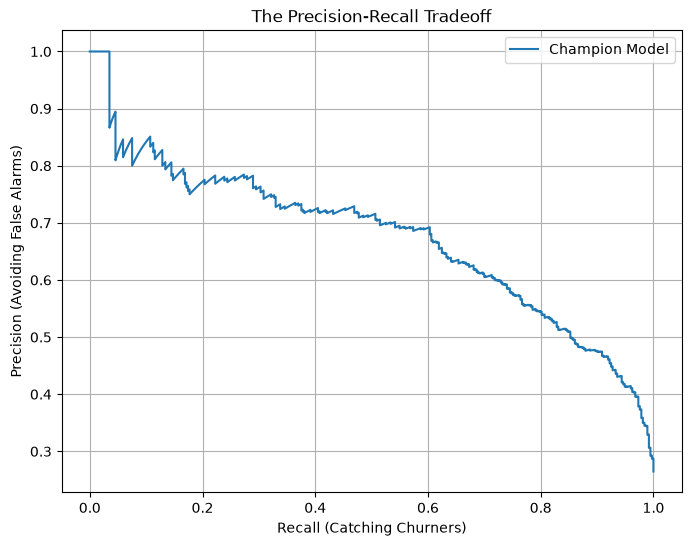

In [158]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get the probabilities for the test set
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate the curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Plot it
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Champion Model')
plt.xlabel('Recall (Catching Churners)')
plt.ylabel('Precision (Avoiding False Alarms)')
plt.title('The Precision-Recall Tradeoff')
plt.legend()
plt.grid(True)
plt.show()